## Separation

The function of this notebook is to do the following:

1. Separate raw EEG data from processed EEG data calculated by **MM**.
2. Extract trials from calibration data
3. Produce new folders for each trial, each with their own set of files.

### Step 0: Imports & Global Variables

In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from components import timestamps
from components import file_handling
importlib.reload(timestamps)
importlib.reload(file_handling)

pd.set_option('display.max_colwidth', None)   # Show full cell contents
pd.set_option('display.max_columns', None)    # Show all columns
pd.set_option('display.width', None)          # Don't wrap lines
pd.set_option('display.float_format', '{:.0f}'.format)

## Step 1: Find all participant files

A simple walk to identify, based on `_ACTIVE_PARTICIPANTS`, which files are present for which particcipants.

In [2]:
_DATA_DIR = "data/"
_ACTIVE_PARTICIPANTS = [
    'P1',
    'PI2',
    'P2',
    'P3',
    'P4_Muse2',
    'P5'
]

p_dirs = [{'p':p, 'd':os.path.join(_DATA_DIR, p+'/')} for p in _ACTIVE_PARTICIPANTS]
files = [{'p':p['p'], 'input_dir': p['d'], 'trials':[], 'files':file_handling.find_files(p['d'])} for p in p_dirs]

### Step 2: Generate output folders

We want to generate `trials/` subdirectories for each participant.

In [3]:
for p in files:
    # Extrapolate the output directory
    output_dir = os.path.join(p['input_dir'], 'trials/')
    
    # Create, delete existing if discovered
    file_handling.mkdirs(output_dir)

    # Save the results
    p['output_dir'] = output_dir

### Step 3: Extract rest EEG

The first major thing we do is trying to read EEG data. We do this first with `eeg_rest.csv`.

There are two helper functions, `handle_eeg()` and `separate_eeg()`, that we generate here. We use these functions to pre-process EEG data. We can use these functions elsewhere too.

In [4]:
def handle_eeg(f:str):
    # Read the `eeg_rest.csv` as a DataFrame
    df = pd.read_csv(f)

    # Generate timestamp features
    df['unix_ms'] = df['TimeStamp'].apply(timestamps.timestamp_to_unix_milliseconds)
    df['unix_sec'] = df['TimeStamp'].apply(timestamps.timestamp_to_unix_seconds)    
    df['rel_sec'] = df['unix_sec'] - df['unix_sec'].iloc[0]
    df['rel_ms'] = df['unix_ms'] - df['unix_ms'].iloc[0]
    
    # separate blinks from raw data
    signals = df[df['Elements'].isna()]
    blinks = df[df['Elements']=='/muse/elements/blink']
    blinks = blinks[['TimeStamp', 'unix_sec', 'unix_ms', 'rel_sec', 'rel_ms']]    
    
    # return 
    return signals, blinks

In [5]:
# Separate columns, between raw and processed
def separate_eeg( df:pd.DataFrame, time_colnames=['unix_sec','unix_ms', 'rel_sec', 'rel_ms'] ):
    # Rename scheme for raw features
    raw_colnames = {
        'RAW_TP9':'TP9', 
        'RAW_TP10':'TP10', 
        'RAW_AF7':'AF7', 
        'RAW_AF8':'AF8'
    }

    # No need to rename processed features, but we need a list of them to extract them
    processed_colnames = [
        'Delta_TP9','Delta_TP10','Delta_AF7','Delta_AF8',
        'Theta_TP9', 'Theta_TP10', 'Theta_AF7', 'Theta_AF8',
        'Alpha_TP9', 'Alpha_TP10', 'Alpha_AF7', 'Alpha_AF8',
        'Beta_TP9', 'Beta_TP10', 'Beta_AF7', 'Beta_AF8',
        'Gamma_TP9', 'Gamma_TP10', 'Gamma_AF7', 'Gamma_AF8'
    ]
    
    # Get raw data, then rename the features
    raw_df = df[[*time_colnames, *list(raw_colnames.keys())]]
    raw_df.rename(columns=raw_colnames, inplace=True)
    
    # Get processed data
    processed_df = df[[*time_colnames, *processed_colnames]]
    
    # Return
    return raw_df, processed_df


In [6]:
for p in files:
    # If `files` doesn't even have any files, then we skip
    if len(p['files']) == 0:
        print(f"No files detected for participant {p['p']}. Exiting early.", file=sys.stderr)
        continue

    # if `files` doesn't contain `eeg_rest.csv`, then we skip
    if 'eeg_rest.csv' not in p['files']: 
        print(f"`eeg_rest.csv` is not among participant {p['p']}'s files. Existing early.", file=sys.stderr)
        continue

    # Read the `eeg_rest.csv` as a DataFrame
    eeg, blinks = handle_eeg(os.path.join(p['input_dir'], 'eeg_rest.csv'))
    raw, processed = separate_eeg(eeg)

    # Have 3 versions: `raw`, `processed`, and `blinks`
    # Store the files inside of a `rest` directory
    output_dir = os.path.join(p['output_dir'], 'rest/')
    file_handling.mkdirs(output_dir)
    raw.to_csv(os.path.join(output_dir, 'raw.csv'))
    processed.to_csv(os.path.join(output_dir, 'processed.csv'))
    blinks.to_csv(os.path.join(output_dir, 'blinks.csv'))
    

/var/folders/r7/zkk06b910nd7ysr86dhn0yqh0000gn/T/ipykernel_21489/3143368414.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
/var/folders/r7/zkk06b910nd7ysr86dhn0yqh0000gn/T/ipykernel_21489/3143368414.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
/var/folders/r7/zkk06b910nd7ysr86dhn0yqh0000gn/T/ipykernel_21489/3143368414.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

## Step 4: Parse Trials

This is an intermediary step because we need to look at two things: 

- All the calibration files in `files`
- the `eye.csv`, which nests all the trial filenames and their starting timestamps

The issue is that, from the `eye.csv`, we need to extract all the trial start and end points. We **also** need to extract the start and end timestamps from the calibration files itself. Ideally, we would be able to produce a single DataFrame that contains all the the necessary data.

### 4a. Calculating Calibration Files Relative to Eye Data

Let's generate a visualization for each participant that showcases, relative to `eye.csv`, when each calibration file was generated.

In [7]:
def eye_calibration_timeline(_PID, _EYE_F, _CALIBRATION_FS):
    
    # Get the eye dataframe
    eye_df = pd.read_csv(_EYE_F)

    # --- Get overall time range ---
    start_time = eye_df["unix_ms"].min()
    end_time = eye_df["unix_ms"].max()

    # --- Collect first timestamps from small files ---
    markers = []
    for f in _CALIBRATION_FS:
        df = pd.read_csv(f)
        if "unix_ms" not in df.columns:
            continue  # skip if missing
        first_time = df["unix_ms"].iloc[0]
        markers.append((f"{os.path.basename(f)}\n{first_time}", first_time))

    # --- Plot ---
    plt.figure(figsize=(12, 4))
    plt.plot(eye_df["unix_ms"], [0]*len(eye_df), alpha=0.2, label="Eye dataset timeline")

    # Add vertical markers for each smaller file
    for name, t in markers:
        plt.axvline(x=t, color='red', linestyle='--', alpha=0.7)
        plt.text(t, 0.1, name, rotation=90, verticalalignment='bottom', fontsize=8)

    # Add a vertical marker for the start and ends too.
    plt.axvline(x=start_time, color='blue', linestyle='--', alpha=0.7)
    plt.text(start_time, 0.1, f"Eye Start\n{start_time}", rotation=90, verticalalignment='bottom', fontsize=7.5)

    # Render other stuff
    plt.xlim(start_time, end_time)
    plt.xlabel("Unix time (ms)")
    plt.yticks([])
    plt.title(f"Participant {_PID}: Timeline of Eye Data to Calibrations:")
    plt.legend()
    plt.tight_layout()
    plt.show()

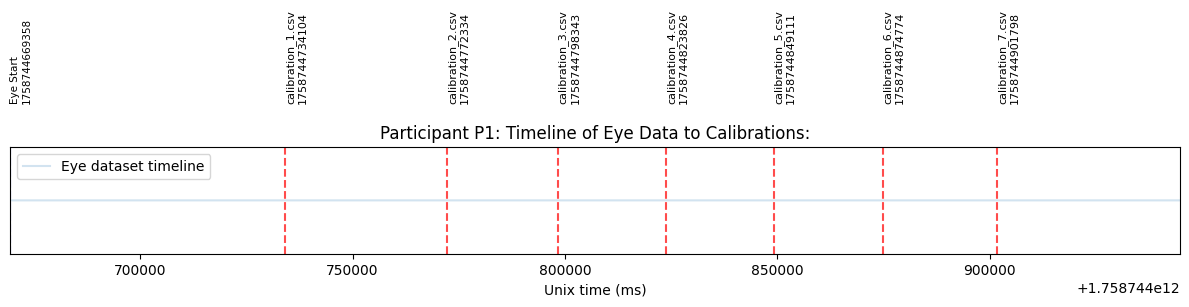

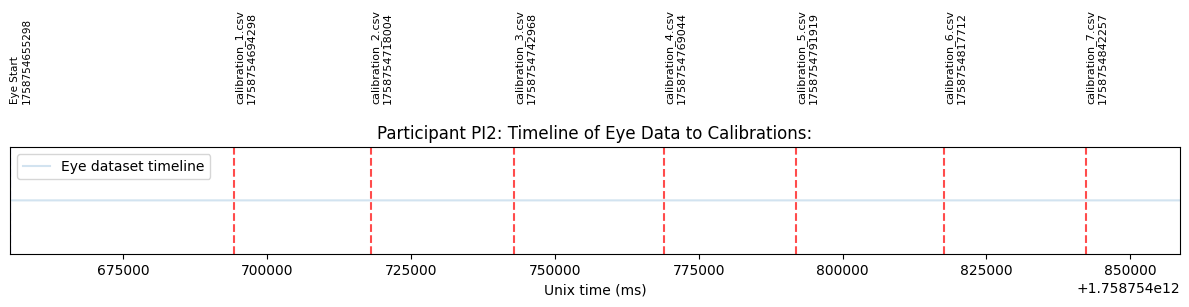

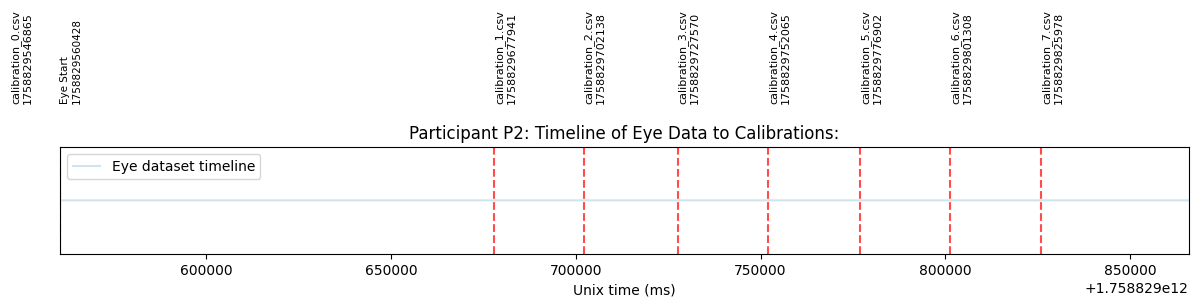

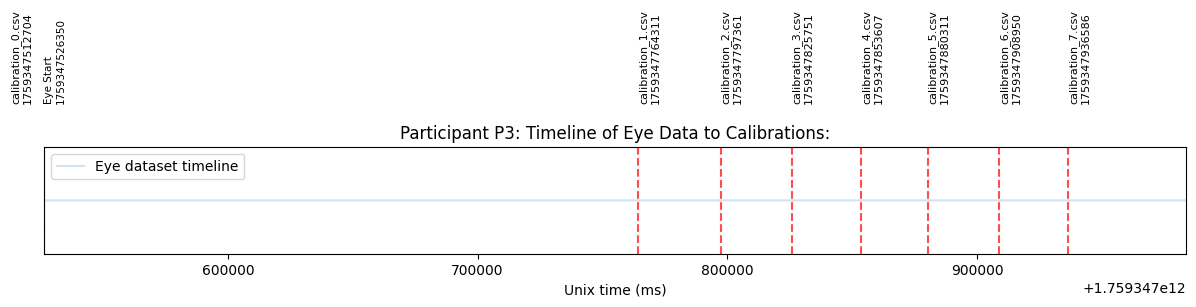

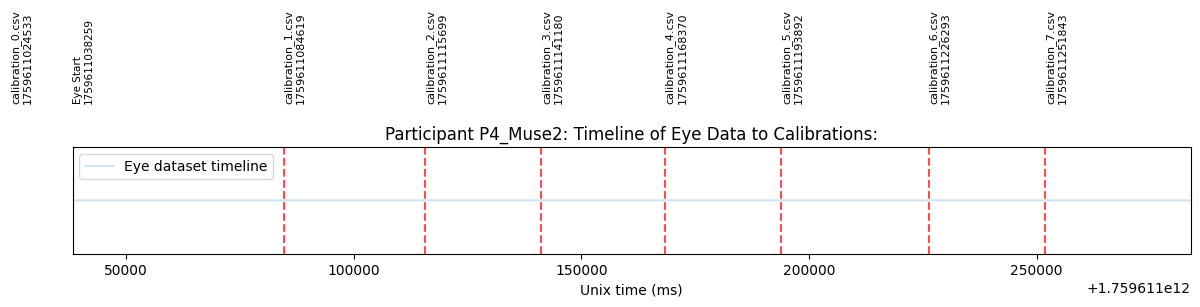

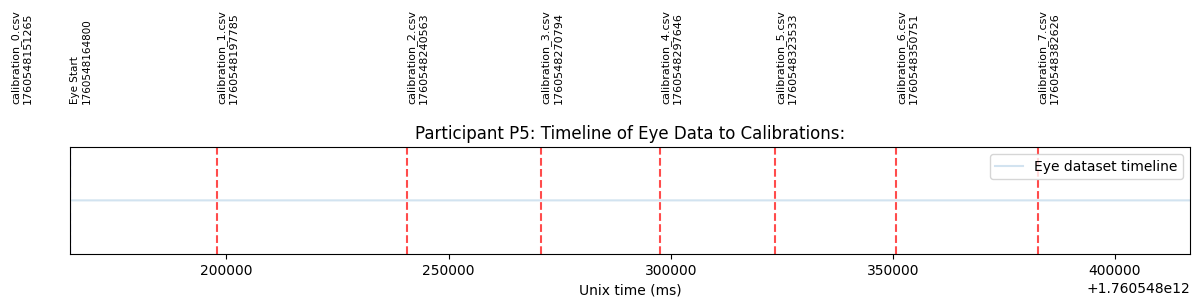

In [8]:
for p in files:
    # Double-check the `eye.csv` is provided in the participant's data files. If not, then skip
    if 'eye.csv' not in p['files']:
        print(f"`eye.csv` is not present in participant {p['p']}'s files! Exiting early.", file=sys.stderr)
        continue

    # Get all calibration files, check if any exist, skip if not
    calibration_files = [os.path.join(p['input_dir'], f) for f in p['files'] if 'calibration_' in f]
    if len(calibration_files) == 0:
        print(f"No calibration files found in participant {p['p']}'s files! Exiting early.", file=sys.stderr)
        continue

    # Render timeline between eye.csv and all calibration files
    eye_calibration_timeline(p['p'], os.path.join(p['input_dir'], 'eye.csv'), calibration_files)


### 4b. A note about calibration files

There are expected to be **6** trials. These _should_ range from `calibration_1.csv` to `calibration_6.csv`. The 7th calibration file, `calibration_7.csv`, is not an actual trial. It's the final eye calibration step that occurs AFTER the last trial. A majority of participants after PI1 and P1 have a `calibration_test.csv` or `calibration_0.csv` file. This occurs before even the eye tracking data starts recording; it is the first calibration cycle that runs prior to the acclimation phase. We generally try to ignore this one and anything after `calibration_7.csv`.

### 4c. Finalizing trial data, generating trial folders, & moving calibration files

This is the multi-tiered setup:

1. Extract trial names from `eye.csv`
2. Determine trial start and end times, with the help of `calibration_7.csv`
3. Generate folders for each trial
4. Saving cleaned calibration files to each of their respective trial folders
5. Saving a trial dataframe inside of the `trials/` directory of each participant.

In [9]:
_CALIBRATION_COLUMNS = [
    'unix_ms', 
    'frame', 
    'rel_timestamp',
    'event', 
    'overlap_counter'
]

def read_calibration_file(_F:str, correction:bool=True):
    # Read the file
    df = pd.read_csv(_F)

    # Correction, if necessary
    if correction: 
        df = df.iloc[:, :len(_CALIBRATION_COLUMNS)]
        df.columns = _CALIBRATION_COLUMNS

    # Return
    return df

In [10]:
_TRIAL_NAMES = [
    "Trial-ApproachAudio Start", 
    "Trial-BehindAudio Start", 
    "Trial-Behind Start", 
    "Trial-AlleyRunnerAudio Start", 
    "Trial-AlleyRunner Start", 
    "Trial-Approach Start"
]

for p in files:
    # Double-check the `eye.csv` is provided in the participant's data files. If not, then skip
    if 'eye.csv' not in p['files']:
        print(f"`eye.csv` is not present in participant {p['p']}'s files! Exiting early.", file=sys.stderr)
        continue

    # Double-check the `calibration_7.csv` is provided in the participant's data files. If not, then skip
    if 'calibration_7.csv' not in p['files']:
        print(f"`calibration_7.csv` is not present in participant {p['p']}'s files! Exiting early.", file=sys.stderr)
        continue

    # Load eye.csv
    eye_df = pd.read_csv(os.path.join(p['input_dir'], 'eye.csv'))

    # Extract only trial rows
    trials_df = eye_df[eye_df['event'].isin(_TRIAL_NAMES)]
    trials_df = trials_df[['event', 'unix_ms', 'frame']].rename(columns={'event':'trial_name', 'unix_ms':'start_unix_ms', 'frame':'start_frame'})
    trials_df = trials_df.sort_values('start_unix_ms')

    # Calculate ends of trials by looking at the next row.
    trials_df['end_unix_ms'] = trials_df['start_unix_ms'].shift(-1)
    trials_df['end_frame'] = trials_df['start_frame'].shift(-1)

    # To get the last entries of `end_unix_ms` and `end_frame`, we have to look at `calibration_7.csv`
    last_cal_df = read_calibration_file(os.path.join(p['input_dir'], 'calibration_7.csv'))
    last_cal_first = last_cal_df.iloc[0].to_dict()
    last_cal_start = last_cal_first['unix_ms']
    last_cal_frame = last_cal_first['frame']

    # then append it to our trials
    trials_df.at[trials_df.index[-1], 'end_unix_ms'] = last_cal_start
    trials_df.at[trials_df.index[-1], 'end_frame'] = last_cal_frame

    # Cleanup: 
    # 1. Create "trial #" column that numbers each trial, 
    # 2. Rename trials to remove extraneous info, and 
    # 3. Mark if a trial is one that involves audio or not
    trials_df['trial_id'] = range(1, len(trials_df) + 1)
    trials_df['trial_name'] = trials_df['trial_name'].apply(lambda x: (x.split(" ")[0]).split('-')[1])
    trials_df['trial_audio'] = trials_df['trial_name'].apply(lambda x: "Audio" in x)

    # Create a directory for each trial
    for index, row in trials_df.iterrows():
        # Create the directory
        tdir = os.path.join(p['output_dir'], f"{row['trial_id']}/")
        file_handling.mkdirs(tdir)
        p['trials'].append(f"{row['trial_id']}")

        # Create a `calibration` subdirectory inside the trial directory
        cdir = os.path.join(tdir, 'calibration/')
        file_handling.mkdirs(cdir)

        # Find the calibration file associated with this trial. Skip if not found
        if f"calibration_{row['trial_id']}.csv" not in p['files']:
            print(f"Calibration file 'calibration_{row['trial_id']}.csv' not present in participant {p['p']}'s files! Exiting early.", file=sys.stderr)
            continue
        
        # Save calibration file (cleaned up one)
        cdf = read_calibration_file(os.path.join(p['input_dir'], f"calibration_{row['trial_id']}.csv"))
        cdf.to_csv(os.path.join(cdir, "calibration.csv"))

    # Create a csv with the trial data.
    # We save the filename as "simulations.csv" instead, because these timestamps
    # are only captured during the simulation.
    trials_df.to_csv(os.path.join(p['output_dir'], 'simulations.csv'))

## Step 5: Separate EEG, eye, and pedestrians data based on trial data

With the trial data saved to `trials/trials.csv` for each participant, we can begin to start parsing `eeg_vr.csv`, `eye.csv`, and `pedestrians.csv`. We need to be able to split the data between each trial, and then for each trial, split between calibration and actual data.

In [11]:
for p in files:

    # Double-check the `eye.csv` is provided in the participant's data files. If not, then skip
    if 'eye.csv' not in p['files']:
        print(f"`eye.csv` is not present in participant {p['p']}'s files! Exiting early.", file=sys.stderr)
        continue

    # Double-check the `eeg_vr.csv` is provided in the participant's data files. If not, then skip
    if 'eeg_vr.csv' not in p['files']:
        print(f"`eeg_vr.csv` is not present in participant {p['p']}'s files! Exiting early.", file=sys.stderr)
        continue

    # Double-check that `pedestrians.csv` is provided in the participant's data files. If not, then skip
    if 'pedestrians.csv' not in p['files']:
        print(f"`pedestrians.csv` is not present in participant {p['p']}'s files! Exiting early.", file=sys.stderr)
        continue

    # Read the `eeg_vr.csv`, `eye.csv`, and `pedestrians.csv`
    eeg, muse_blinks = handle_eeg(os.path.join(p['input_dir'], 'eeg_vr.csv'))
    raw, processed = separate_eeg(eeg)
    eye = pd.read_csv(os.path.join(p['input_dir'], 'eye.csv'))
    positions = pd.read_csv(os.path.join(p['input_dir'], 'pedestrians.csv'))

    # Let's save these versions of the files inside of `trials`
    # Start saving our files appropriately. First, we save the processed versions of the trial data
    muse_blinks.to_csv(p['output_dir'] + 'muse_blinks.csv')
    raw.to_csv(p['output_dir'] + 'eeg_raw.csv')
    processed.to_csv(p['output_dir'] + 'eeg_processed.csv')
    eye.to_csv(p['output_dir'] + 'eye.csv')
    positions.to_csv(p['output_dir'] + 'positions.csv')

    # Read the simulation data
    sims_df = pd.read_csv(os.path.join(p['output_dir'], 'simulations.csv')).drop(columns=['Unnamed: 0'])

    # Before we start iterating through the trials, let's save our calibrations into a new `calibrations.csv` file that's saved insie the output directory, alongside `trials.csv`
    cal_trial_ids = []
    cal_start_times = []
    cal_start_frames = []
    cal_end_times = []
    cal_end_frames = []

    # Iterate through each trial row
    for index, trial in sims_df.iterrows():
        # Get the start and end times of the trial
        trial_start_time = trial['start_unix_ms']
        trial_start_frame = trial['start_frame']
        trial_end_time = trial['end_unix_ms']
        trial_end_frame = trial['end_frame']
        trial_id = trial['trial_id']
        
        # Read the calibration data for the current trial, and grab the start/end times/frames
        cal_dir = os.path.join(p['output_dir'], f'{trial_id}/calibration/')
        cdf = pd.read_csv(cal_dir + 'calibration.csv')
        cal_start_end = cdf[cdf['event'].isin(['Start','End'])]
        cal_start_row = cal_start_end[cal_start_end['event'] == 'Start'].iloc[0]
        cal_end_row = cal_start_end[cal_start_end['event'] == 'End'].iloc[0]
        cal_start_time = cal_start_row['unix_ms']
        cal_start_frame = cal_start_row['frame']
        cal_end_time = cal_end_row['unix_ms']
        cal_end_frame = cal_end_row['frame']

        # Now, we need to extract the dataset subsets only relevant to this current trial
        # The only dataset that doesn't have unix milliseconds is `positions`

        # Firstly, the entire trial data from calibration start to simulation end
        trial_dfs = {
            'muse_blinks': muse_blinks[muse_blinks['unix_ms'].between(cal_start_time, trial_end_time)],
            'raw': raw[raw['unix_ms'].between(cal_start_time, trial_end_time)],
            'processed': processed[processed['unix_ms'].between(cal_start_time, trial_end_time)],
            'eye': eye[eye['unix_ms'].between(cal_start_time, trial_end_time)],
            'positions': positions[positions['frame'].between(cal_start_frame, trial_end_frame)]
        }

        # Secondly, only the data pertaining to calibration stages
        cal_dfs = {
            'muse_blinks': muse_blinks[muse_blinks['unix_ms'].between(cal_start_time, cal_end_time)],
            'raw': raw[raw['unix_ms'].between(cal_start_time, cal_end_time)],
            'processed': processed[processed['unix_ms'].between(cal_start_time, cal_end_time)],
            'eye': eye[eye['unix_ms'].between(cal_start_time, cal_end_time)],
            'positions': positions[positions['frame'].between(cal_start_frame, cal_end_frame)]
        }

        # Thirdly, only the data pertaining to simulation stages
        sim_dfs = {
            'muse_blinks': muse_blinks[muse_blinks['unix_ms'].between(trial_start_time, trial_end_time)],
            'raw': raw[raw['unix_ms'].between(trial_start_time, trial_end_time)],
            'processed': processed[processed['unix_ms'].between(trial_start_time, trial_end_time)],
            'eye': eye[eye['unix_ms'].between(trial_start_time, trial_end_time)],
            'positions': positions[positions['frame'].between(trial_start_frame, trial_end_frame)]
        }

        # Saving! 
        # Firstly, we start saving our calibration files, as we already have the calibration directory
        cal_dfs['muse_blinks'].to_csv(cal_dir + 'muse_blinks.csv')
        cal_dfs['raw'].to_csv(cal_dir + 'eeg_raw.csv')
        cal_dfs['processed'].to_csv(cal_dir + 'eeg_processed.csv')
        cal_dfs['eye'].to_csv(cal_dir + 'eye.csv')
        cal_dfs['positions'].to_csv(cal_dir + 'positions.csv')

        # Secondly, make a directory for the simulation and place our dataframes in there
        sim_dir = os.path.join(p['output_dir'], f'{trial_id}/simulation/')
        file_handling.mkdirs(sim_dir)
        sim_dfs['muse_blinks'].to_csv(sim_dir + 'muse_blinks.csv')
        sim_dfs['raw'].to_csv(sim_dir + 'eeg_raw.csv')
        sim_dfs['processed'].to_csv(sim_dir + 'eeg_processed.csv')
        sim_dfs['eye'].to_csv(sim_dir + 'eye.csv')
        sim_dfs['positions'].to_csv(sim_dir + 'positions.csv')

        # Lastly, we also make a directory for the combiend data
        comb_dir = os.path.join(p['output_dir'], f'{trial_id}/combined/')
        file_handling.mkdirs(comb_dir)
        trial_dfs['muse_blinks'].to_csv(comb_dir + 'muse_blinks.csv')
        trial_dfs['raw'].to_csv(comb_dir + 'eeg_raw.csv')
        trial_dfs['processed'].to_csv(comb_dir + 'eeg_processed.csv')
        trial_dfs['eye'].to_csv(comb_dir + 'eye.csv')
        trial_dfs['positions'].to_csv(comb_dir + 'positions.csv')

        # Record our calibrations
        cal_trial_ids.append(trial_id)
        cal_start_times.append(cal_start_time)
        cal_start_frames.append(cal_start_frame)
        cal_end_times.append(cal_end_time)
        cal_end_frames.append(cal_end_frame)

    # Closing things out, let's save our `calibrations.csv` file
    pd.DataFrame({
        'trial_id': cal_trial_ids,
        'start_unix_ms': cal_start_times,
        'start_frame': cal_start_frames,
        'end_unix_ms': cal_end_times,
        'end_frame': cal_end_frames
    }).to_csv(os.path.join(p['output_dir'], 'calibrations.csv'))


/var/folders/r7/zkk06b910nd7ysr86dhn0yqh0000gn/T/ipykernel_21489/3143368414.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
/var/folders/r7/zkk06b910nd7ysr86dhn0yqh0000gn/T/ipykernel_21489/3143368414.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
`pedestrians.csv` is not present in participant P2's files! Exiting early.
/var/folders/r7/zkk06b910nd7ysr86dhn0yqh0000gn/T/ipykernel_21489/3143368414.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in

## What's to be expected from running this notebook?

At this point, if you were to run through all the code blocks in order, then you should expect the following result:

1. Within each participant's directory in `src/data` is a new `trials/` directory.
2. Inside the `trials/` directory, you should see the following:
    - Each trial, marked from `1` to `6`
    - `rest/` that represents the baseline EEG data collection prior to all trials
    - `calibrations.csv` and `simulations.csv` = store timestamps for all calibration and simulation phases across the entire timeline.
    - `eeg_processed.csv` and `eeg_raw.csv` = contain the separated EEG signal data from the Mind Monitor application. These only contain signals and do not contain any blink data.
    - `muse_blinks.csv` = extracted blink data recorded by Mind Monitor from the EEG data.
    - `eye.csv` and `positions.csv` = the eye tracking and positional data recorded across the entire participant timeline.
3. Inside of each trial directory, you should see 3 subdirectories: `calibration/`, `simulation/`, and `combined/`. These should make sense: `calibration/` contains all data pertaining only to the calibration phase; `simulation/` contains all data pertaining only to the simulation phase, and `combined/` is the combined data. Each of these directories has the following files:
    - `calibrations.csv` and `simulations.csv` = store timestamps for all calibration and simulation phases across the entire timeline.
    - `eeg_processed.csv` and `eeg_raw.csv` = contain the separated EEG signal data from the Mind Monitor application. These only contain signals and do not contain any blink data.
    - `muse_blinks.csv` = extracted blink data recorded by Mind Monitor from the EEG data.
    - `eye.csv` and `positions.csv` = the eye tracking and positional data recorded across the entire participant timeline.

## What's Next?

The next notebook to run is [`alignment.ipynb`](./alignment.ipynb), which endeavors to determine what's the best way to align the blink data from the Mind Monitor application, the raw EEG data, and the eye tracking data.